# Exercise: Length of Stay

**Module 3: Probability Distributions** | Lean Six Sigma Data Analytics

---

## The Scenario

You work at a **hospital** and have gathered data on the **length of stay** of your patients.

**Question:** What is the percentage of patients with a maximum stay of **10 days**?

You have gathered data on **321 patients**.

---

## Try It Yourself

Before looking at the solution:
1. Load the data
2. Find the distribution that fits best (probability plot)
3. Use the empirical CDF to find the percentage

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')


Data loaded successfully!


In [2]:
# Load Length of Stay data
los_df = pd.read_excel(xlsx, sheet_name='Length of stay', skiprows=5, usecols=[0])
los_df.columns = ['LOS']
los_df = los_df.dropna()
los_df['LOS'] = pd.to_numeric(los_df['LOS'], errors='coerce')
los_df = los_df.dropna()

los_data = los_df['LOS'].values

print('Length of Stay Data')
print(f'Sample size: {len(los_data)} patients')
print(f'Mean: {los_data.mean():.1f} days')
print(f'Median: {np.median(los_data):.1f} days')
print(f'Min: {los_data.min():.0f}, Max: {los_data.max():.0f} days')

Length of Stay Data
Sample size: 321 patients
Mean: 10.6 days
Median: 10.0 days
Min: 6, Max: 22 days


---

## Solution

### Step 1: Find the Best Distribution (Probability Plot)

To find a percentage, you need an **Empirical CDF**.

But first, you must determine the **distribution that fits best** using a **probability plot**.

**Minitab:** Graph > Probability Plot > Single

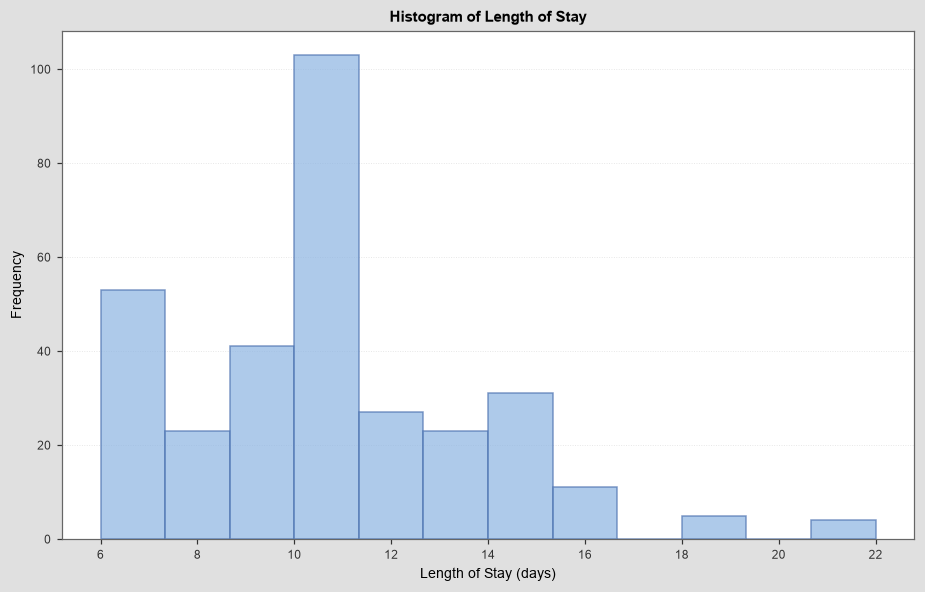

The data appears slightly right-skewed.
Let us test Normal, Weibull, and Lognormal distributions.


In [3]:
# Histogram to see the shape
plt.figure(figsize=(10, 6))
plt.hist(los_data, bins=12, edgecolor=ms.HIST_EDGE, alpha=0.7, color=ms.HIST_FILL)
plt.xlabel('Length of Stay (days)')
plt.ylabel('Frequency')
plt.title('Histogram of Length of Stay')
plt.show()

print('The data appears slightly right-skewed.')
print('Let us test Normal, Weibull, and Lognormal distributions.')

C:\Users\dmnandlu\AppData\Local\Temp\ipykernel_10336\3911370605.py:6: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_norm, _, _ = stats.anderson(los_data, dist='norm')


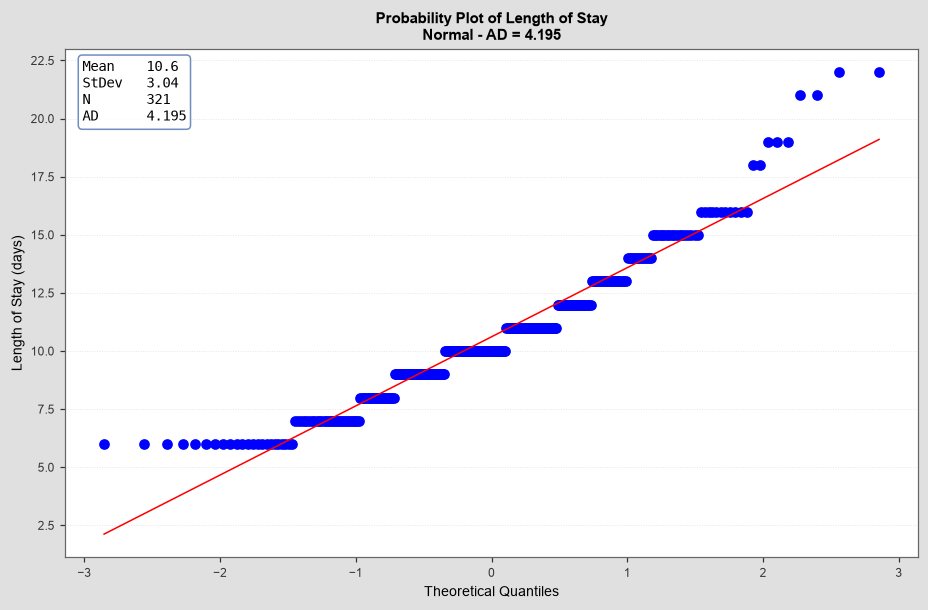

Normal distribution: Points curve away from the line.
Not a good fit.


In [4]:
# Probability Plot: Normal Distribution
fig, ax = plt.subplots(figsize=(10, 6))
res = stats.probplot(los_data, dist='norm', plot=ax)

# Anderson-Darling statistic
ad_norm, _, _ = stats.anderson(los_data, dist='norm')

ax.set_title(f'Probability Plot of Length of Stay\nNormal - AD = {ad_norm:.3f}')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Length of Stay (days)')

# Stats text box
stats_text = f'Mean    {los_data.mean():.1f}\nStDev   {los_data.std():.2f}\nN       {len(los_data)}\nAD      {ad_norm:.3f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        family='monospace')

plt.show()

print('Normal distribution: Points curve away from the line.')
print('Not a good fit.')

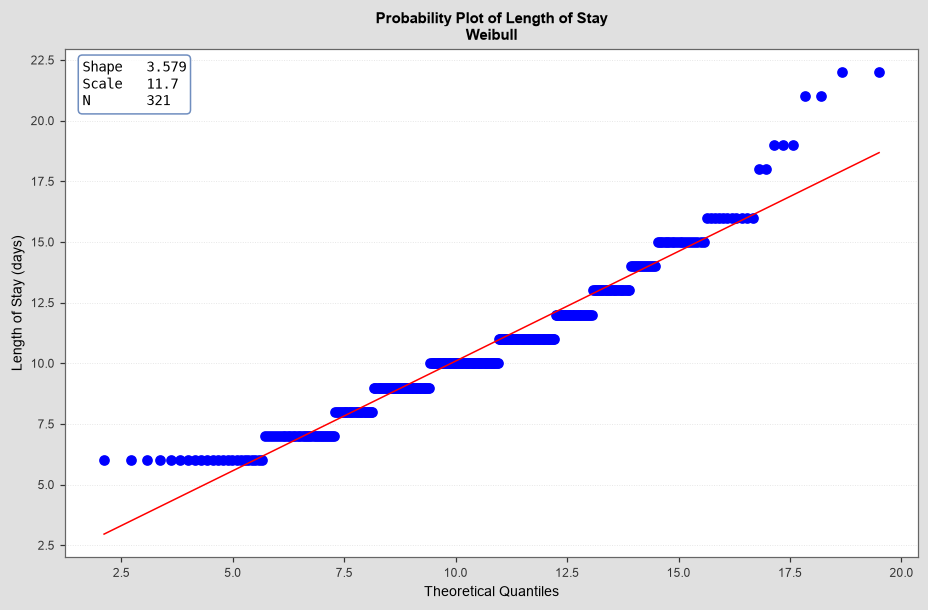

Weibull distribution: Does not fit better than Normal.


In [5]:
# Probability Plot: Weibull Distribution
shape, loc, scale = stats.weibull_min.fit(los_data, floc=0)

fig, ax = plt.subplots(figsize=(10, 6))
res = stats.probplot(los_data, dist=stats.weibull_min, sparams=(shape, loc, scale), plot=ax)

ax.set_title(f'Probability Plot of Length of Stay\nWeibull')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Length of Stay (days)')

# Stats text box
stats_text = f'Shape   {shape:.3f}\nScale   {scale:.1f}\nN       {len(los_data)}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        family='monospace')

plt.show()

print('Weibull distribution: Does not fit better than Normal.')

C:\Users\dmnandlu\AppData\Local\Temp\ipykernel_10336\3394325690.py:8: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_lognorm, _, _ = stats.anderson(log_los, dist='norm')


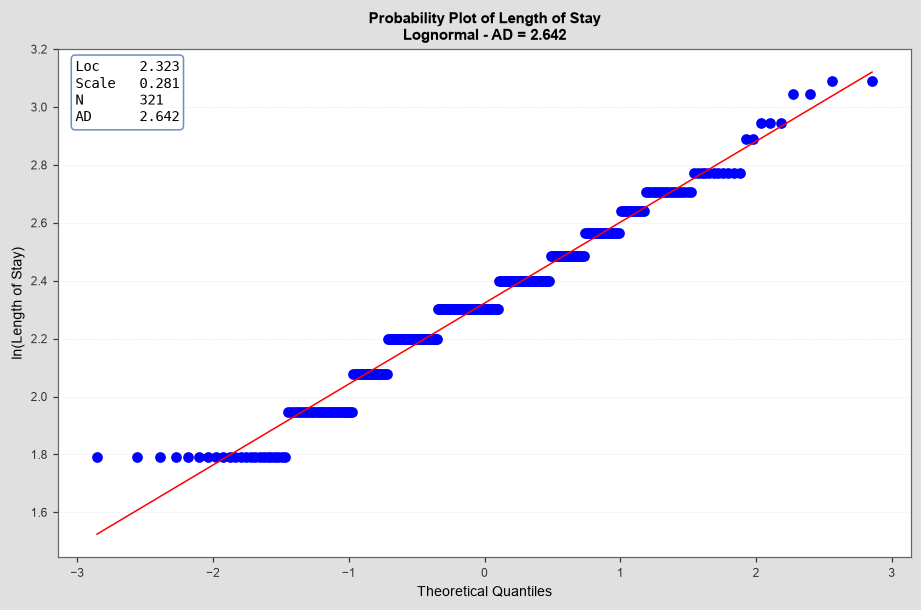

Lognormal distribution: Best fit!
Points are more or less on the straight line.
(Except for a few measurements near the bottom.)


In [6]:
# Probability Plot: Lognormal Distribution
log_los = np.log(los_data)

fig, ax = plt.subplots(figsize=(10, 6))
res = stats.probplot(log_los, dist='norm', plot=ax)

# Anderson-Darling on log-transformed data
ad_lognorm, _, _ = stats.anderson(log_los, dist='norm')

ax.set_title(f'Probability Plot of Length of Stay\nLognormal - AD = {ad_lognorm:.3f}')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('ln(Length of Stay)')

# Stats text box
stats_text = f'Loc     {log_los.mean():.3f}\nScale   {log_los.std():.3f}\nN       {len(los_data)}\nAD      {ad_lognorm:.3f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        family='monospace')

plt.show()

print('Lognormal distribution: Best fit!')
print('Points are more or less on the straight line.')
print('(Except for a few measurements near the bottom.)')

In [7]:
# Compare AD statistics
print('COMPARISON OF DISTRIBUTION FITS')
print('=' * 50)
print(f'Normal:    AD = {ad_norm:.3f}')
print(f'Lognormal: AD = {ad_lognorm:.3f}  <- LOWEST (best fit)')
print()
print('CONCLUSION: Lognormal distribution fits Length of Stay best.')

COMPARISON OF DISTRIBUTION FITS
Normal:    AD = 4.195
Lognormal: AD = 2.642  <- LOWEST (best fit)

CONCLUSION: Lognormal distribution fits Length of Stay best.


---

### Step 2: Create the Empirical CDF

Now we can make an **Empirical CDF** to answer the question:

**What is the percentage of patients with a maximum stay of 10 days?**

**Minitab:** Graph > Empirical CDF > Single > Distribution: Lognormal

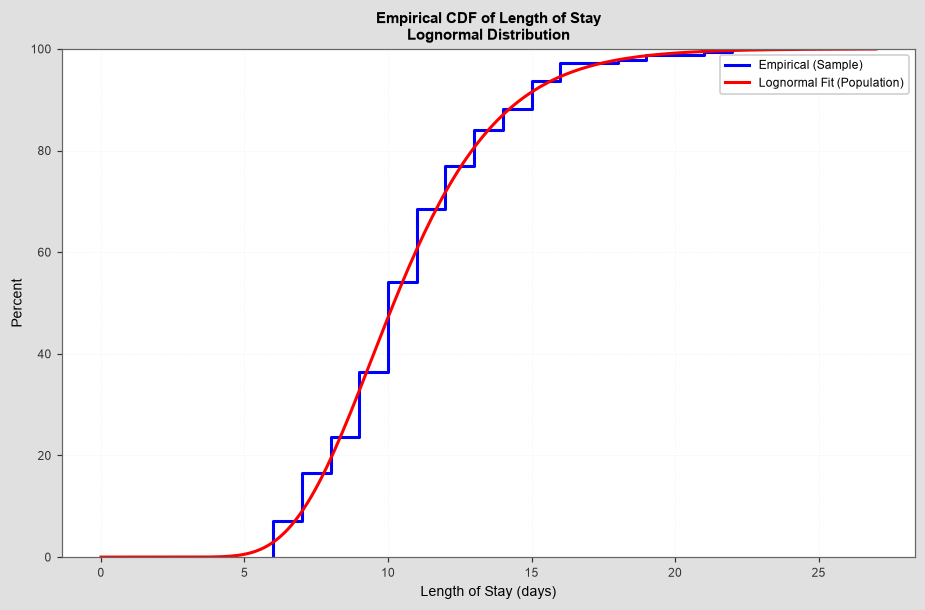

In [8]:
# Empirical CDF with Lognormal Distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Empirical CDF (blue step function)
sorted_data = np.sort(los_data)
ecdf_y = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
ax.step(sorted_data, ecdf_y, where='post', color='blue', lw=2, label='Empirical (Sample)')

# Fitted Lognormal CDF (red curve)
mu_log = log_los.mean()
sigma_log = log_los.std()
x_range = np.linspace(0, los_data.max() + 5, 200)
lognorm_cdf = stats.lognorm.cdf(x_range, s=sigma_log, scale=np.exp(mu_log)) * 100
ax.plot(x_range, lognorm_cdf, 'r-', lw=2, label='Lognormal Fit (Population)')

ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Percent')
ax.set_title('Empirical CDF of Length of Stay\nLognormal Distribution')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.show()

---

### Step 3: Answer the Question

Use the fitted lognormal distribution to find the percentage at 10 days.

In [9]:
# Calculate percentage at 10 days
target = 10
pct_10 = stats.lognorm.cdf(target, s=sigma_log, scale=np.exp(mu_log)) * 100

print('ANSWER')
print('=' * 50)
print(f'What is the percentage of patients with a maximum stay of {target} days?')
print()
print(f'Answer: {pct_10:.1f}% of patients have a maximum stay of {target} days.')

ANSWER
What is the percentage of patients with a maximum stay of 10 days?

Answer: 47.2% of patients have a maximum stay of 10 days.


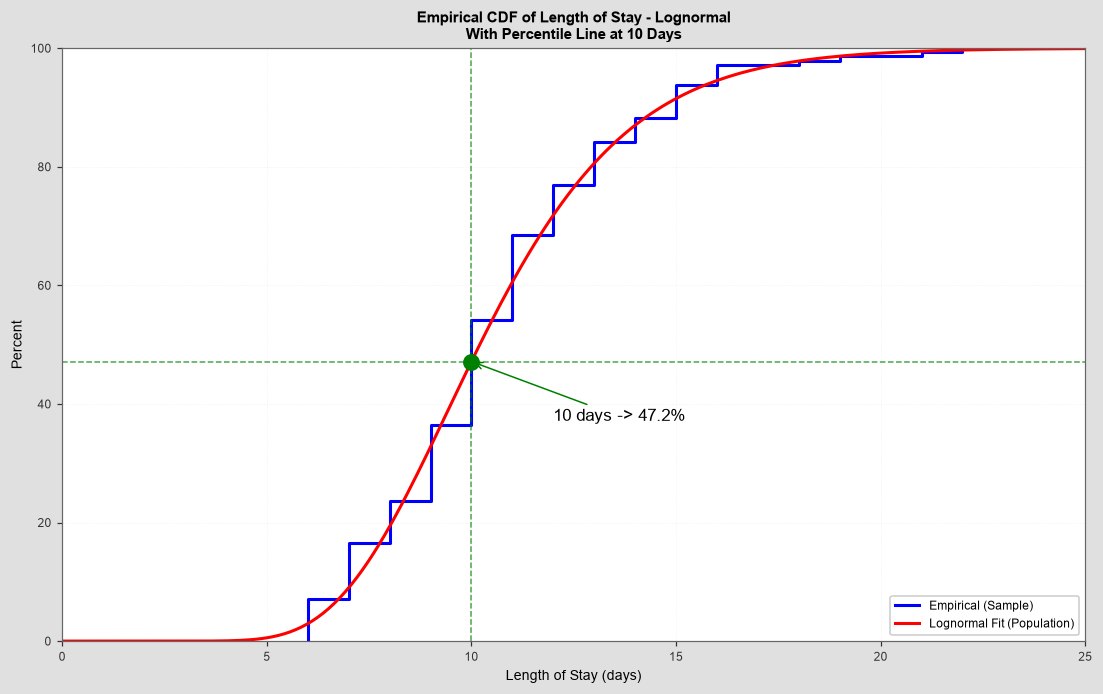

In [10]:
# Empirical CDF with percentile line at 10 days
fig, ax = plt.subplots(figsize=(12, 7))

# Empirical CDF
ax.step(sorted_data, ecdf_y, where='post', color='blue', lw=2, label='Empirical (Sample)')

# Fitted Lognormal CDF
ax.plot(x_range, lognorm_cdf, 'r-', lw=2, label='Lognormal Fit (Population)')

# Percentile lines for 10 days
ax.axvline(x=target, color='green', linestyle='--', alpha=0.7)
ax.axhline(y=pct_10, color='green', linestyle='--', alpha=0.7)
ax.plot(target, pct_10, 'go', markersize=10)
ax.annotate(f'{target} days -> {pct_10:.1f}%', xy=(target, pct_10), xytext=(target+2, pct_10-10),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='green'))

ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Percent')
ax.set_title('Empirical CDF of Length of Stay - Lognormal\nWith Percentile Line at 10 Days')
ax.legend(loc='lower right')
ax.set_xlim(0, 25)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.show()

---

## Summary

In [11]:
# Summary
print('EXERCISE SUMMARY: Length of Stay')
print('=' * 60)
print()
print('Step 1: Find the best distribution (Probability Plot)')
print(f'        Normal:    AD = {ad_norm:.3f}')
print(f'        Lognormal: AD = {ad_lognorm:.3f} <- Best fit')
print()
print('Step 2: Create Empirical CDF with Lognormal distribution')
print()
print('Step 3: Answer the question')
print(f'        {pct_10:.1f}% of patients have a maximum stay of 10 days')
print()
print('KEY LESSON:')
print('  - Always find the correct distribution FIRST (probability plot)')
print('  - Then use Empirical CDF with that distribution to find percentages')

EXERCISE SUMMARY: Length of Stay

Step 1: Find the best distribution (Probability Plot)
        Normal:    AD = 4.195
        Lognormal: AD = 2.642 <- Best fit

Step 2: Create Empirical CDF with Lognormal distribution

Step 3: Answer the question
        47.2% of patients have a maximum stay of 10 days

KEY LESSON:
  - Always find the correct distribution FIRST (probability plot)
  - Then use Empirical CDF with that distribution to find percentages


---

## Key Takeaways

1. **First:** Use probability plot to find the distribution (Normal, Weibull, Lognormal)
2. **Then:** Use Empirical CDF with that distribution to find percentages
3. **Result:** 47.2% of patients have a maximum stay of 10 days

**Workflow:**
```
Probability Plot → Find Best Fit → Empirical CDF → Answer Question
```